In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error

In [9]:
df = pd.read_excel("/content/dataset3.xlsx")

print(df.shape)
df.head()

(10000, 9)


,Crop,Temp (°C),Humidity (%),Moisture (%),RainProb (%),Weather Condition,Pump Status,Irrigation Decision,Yield
0,Tomato,27.6,68.6,58.6,35.0,Sunny,1,1,94.1
1,Wheat,24.3,82.9,58.7,19.3,Sunny,1,1,71.8
2,Rice,33.8,80.1,96.5,50.2,Cloudy,1,1,62.4
3,Wheat,31.0,79.4,42.1,51.2,Cloudy,1,1,81.4
4,Wheat,33.1,30.6,65.9,42.2,Partly Cloudy,1,1,41.2


In [10]:
print(df.isnull().sum())

Crop                   0
Temp (°C)              0
Humidity (%)           0
Moisture (%)           0
RainProb (%)           0
Weather Condition      0
Pump Status            0
Irrigation Decision    0
Yield                  0
dtype: int64


In [16]:
columns_to_dummy = ['Crop', 'Weather Condition']
existing_columns_to_dummy = [col for col in columns_to_dummy if col in df.columns]

if existing_columns_to_dummy:
    df = pd.get_dummies(
        df,
        columns=existing_columns_to_dummy
    )
print(df.columns)

Index(['Temp (°C)', 'Humidity (%)', 'Moisture (%)', 'RainProb (%)',
       'Pump Status', 'Irrigation Decision', 'Yield', 'Crop_Chilli',
       'Crop_Rice', 'Crop_Tomato', 'Crop_Wheat', 'Weather Condition_Cloudy',
       'Weather Condition_Foggy', 'Weather Condition_Partly Cloudy',
       'Weather Condition_Rainy', 'Weather Condition_Sunny'],
      dtype='object')


In [17]:
X = df.drop('Yield', axis=1)

y = df['Yield']

In [18]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        8,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        1
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [22]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1914.6919 - mae: 33.4199 - val_loss: 181.0357 - val_mae: 10.8021
Epoch 2/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 158.2042 - mae: 10.2278 - val_loss: 144.7853 - val_mae: 9.6804
Epoch 3/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 136.7904 - mae: 9.5240 - val_loss: 134.3849 - val_mae: 9.2616
Epoch 4/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 127.1490 - mae: 9.1531 - val_loss: 127.2456 - val_mae: 9.1201
Epoch 5/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 121.0777 - mae: 8.9411 - val_loss: 123.4104 - val_mae: 9.0370
Epoch 6/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 116.8908 - mae: 8.7724 - val_loss: 120.5419 - val_mae: 8.8716
Epoch 7/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 113.5358 - mae: 8.6551 - val_loss: 115.2737 - val_mae: 8.6834
Epoch 8/300
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 111.4616 - mae: 8.5668 - val_loss: 113.7242 - val_mae: 8.6475
Epoch 9/300


In [24]:
predictions = model.predict(X_test)

r2 = r2_score(y_test, predictions)

mae = mean_absolute_error(
    y_test,
    predictions
)

print("R2 Score =", r2)
print("MAE =", mae)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
R2 Score = 0.9802408641181536
MAE = 1.7329303077697755


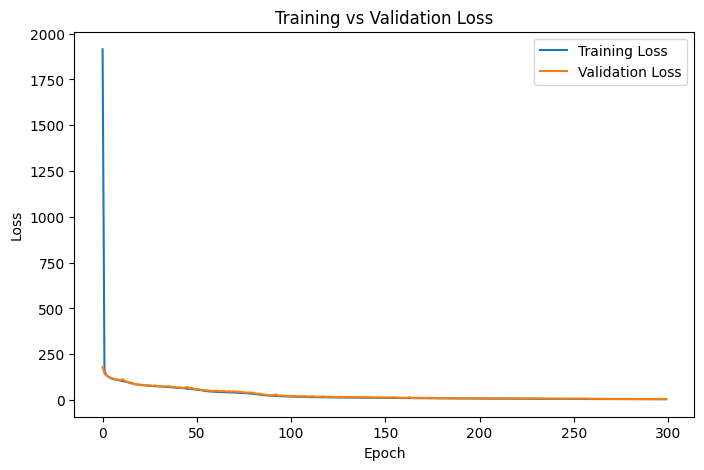

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.show()

In [26]:
model.save("crop_yield_model.h5")

In [27]:
import joblib

joblib.dump(
    scaler,
    "scaler.save"
)

['scaler.save']

Convert Keras Model to TensorFlow Lite

In [29]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "crop_yield_model.h5",
    custom_objects={
        'mse': tf.keras.losses.MeanSquaredError,
        'mae': tf.keras.metrics.MeanAbsoluteError
    }
)

converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

tflite_model = converter.convert()

with open(
    "crop_yield_model.tflite",
    "wb"
) as f:
    f.write(tflite_model)

print("TFLite model created successfully")

Saved artifact at '/tmp/tmpogwdn28_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 15), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135784079705104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135784079715280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135784079715088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135784079710096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135784079714128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135784079715472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135784079716048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135784079715856: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model created successfully


In [30]:
!xxd -i crop_yield_model.tflite > model.h

In [31]:
print("Mean:")
print(scaler.mean_)

print("\nScale:")
print(scaler.scale_)

Mean:
[27.03078 65.87557 61.23298 48.23265  0.6968   0.6968   0.25     0.25
  0.25     0.25     0.1683   0.1664   0.1471   0.2138   0.3044 ]

Scale:
[ 6.43697915 17.17948178 18.82620924 23.37959484  0.4596409   0.4596409
  0.4330127   0.4330127   0.4330127   0.4330127   0.37413248  0.37243931
  0.35420558  0.40998727  0.46015284]


In [33]:
print(X.columns.tolist())

['Temp (°C)', 'Humidity (%)', 'Moisture (%)', 'RainProb (%)', 'Pump Status', 'Irrigation Decision', 'Crop_Chilli', 'Crop_Rice', 'Crop_Tomato', 'Crop_Wheat', 'Weather Condition_Cloudy', 'Weather Condition_Foggy', 'Weather Condition_Partly Cloudy', 'Weather Condition_Rainy', 'Weather Condition_Sunny']
